# Technical training: cloud-native geospatial formats (COG, GeoParquet, STAC, OGC API)

## RQRAD context: soil organic matter (SOM) accumulation potential

This training is part of the RQRAD project on mapping the soil organic matter
(SOM) accumulation potential in Québec. **Agri-SDSS is the platform of this
RQRAD project**: it automates the ingestion, storage, cataloguing and
publication of the geospatial data used by the SOM predictive models.

This notebook is the technical block of the training. It builds the model input layers step by step from open cloud-native data (Sentinel-2, AAFC, Ouranos), reproducing in miniature what the `gis-pipeline` service of Agri-SDSS does in production.

### Objectives

1. Understand what COG, GeoParquet, STAC and the OGC APIs are for. Not only
   in theory, but by handling them directly.
2. Build a small end-to-end geospatial pipeline: open raw data → cloud-native
   formats → STAC catalog.
3. Query a running Agri-SDSS platform through its APIs, to see how these same formats are
   exposed in production.

**Demonstration data**:
   [Download from GitHub](https://github.com/jeremie-durand/geospatial-workflows-guide/blob/main/RQRAD/bdppad_demo_an_2025.gpkg), [Download from Google Drive](https://drive.google.com/file/d/1tz_E4RNyLNWazwvrcamPCqCml-UArIuj/view?usp=sharing)

## Installation

In [ ]:
!pip install -q rasterio==1.4.3 geopandas==1.1.4 pystac[validation]==1.14.3 \
    pystac-client==0.9.0 \
    planetary-computer==1.0.0 xarray==2025.1.1 pydap==3.5.9 \
    pandas==2.2.3 requests==2.32.4 shapely==2.1.1 folium==0.20.0 \
    matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.2/22.2 MB 90.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.5/208.5 kB 15.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.8/41.8 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 73.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 83.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 74.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.8/70.8 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.3/118.3 kB 9.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 5.4 MB/s eta 0:00:00


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Configuration

Pick a regional scenario below (Montérégie by default, or Québec/Estrie): each one combines an area of interest (AOI), a period and a year of the FADQ database of declared agricultural parcels (BDPPAD).

In [78]:
from pathlib import Path

# @markdown ### Regional scenario (changes AOI, dates, AAFC year and BDPPAD file together)
SCENARIO = "Québec (Portneuf)"  # @param ["Montérégie (default)", "Québec (Portneuf)", "Estrie (Coaticook)"]

# @markdown ### Thresholds: free, independent from the scenario
CLOUD_COVER_MAX = 20  # @param {type:"slider", min:0, max:100, step:5}
GDD_BASE_TEMP = 10  # @param {type:"number"}

SCENARIOS = {
    "Montérégie (default)": dict(
        AOI_BBOX=(-73.2, 45.45, -72.7, 45.8),
        START_DATE="2024-06-01",
        END_DATE="2024-08-31",
        AAC_YEAR=2024,
        BDPPAD_DEMO_PATH=Path("/content/drive/MyDrive/Formation RQRAD/bdppad_demo_an_2025.gpkg"),
    ),
    "Québec (Portneuf)": dict(
        AOI_BBOX=(-71.7, 46.65, -71.2, 46.95),
        START_DATE="2024-06-01",
        END_DATE="2024-08-31",
        AAC_YEAR=2024,
        BDPPAD_DEMO_PATH=Path("/content/drive/MyDrive/Formation RQRAD/bdppad_demo_quebec_2025.gpkg"),
    ),
    "Estrie (Coaticook)": dict(
        AOI_BBOX=(-72.2, 45.05, -71.7, 45.35),
        START_DATE="2024-06-01",
        END_DATE="2024-08-31",
        AAC_YEAR=2024,
        BDPPAD_DEMO_PATH=Path("/content/drive/MyDrive/Formation RQRAD/bdppad_demo_estrie_2025.gpkg"),
    ),
}

_active = SCENARIOS[SCENARIO]
AOI_BBOX = _active["AOI_BBOX"]
START_DATE = _active["START_DATE"]
END_DATE = _active["END_DATE"]
AAC_YEAR = _active["AAC_YEAR"]
BDPPAD_DEMO_PATH = _active["BDPPAD_DEMO_PATH"]

# Output directory for the files produced by this workshop
OUTPUT_DIR = Path("formation_output")
OUTPUT_DIR.mkdir(exist_ok=True)

print(f"Active scenario: {SCENARIO}")
print(f"  AOI: {AOI_BBOX}")
print(f"  Period: {START_DATE} → {END_DATE} (AAFC {AAC_YEAR})")
print(f"  Cloud threshold: {CLOUD_COVER_MAX}% · GDD base: {GDD_BASE_TEMP}°C")
print(f"  BDPPAD demo exists: {BDPPAD_DEMO_PATH.exists()}")

Active scenario: Québec (Portneuf)
  AOI: (-71.7, 46.65, -71.2, 46.95)
  Period: 2024-06-01 → 2024-08-31 (AAFC 2024)
  Cloud threshold: 20% · GDD base: 10°C
  BDPPAD demo exists: False


### For another pass (2nd, 3rd...)

Change **`SCENARIO`** (and/or `CLOUD_COVER_MAX` / `GDD_BASE_TEMP`) in the cell above, then **Runtime > Run after** from that cell to re-run everything downstream with the new values.

In [79]:
import requests
import geopandas as gpd

# Shared URL of the Agri-SDSS backend (also used in section 4)
VECTOR_API_URL = "https://agri-sdss.duckdns.org/vector-api"


def fetch_bdppad_parcels_from_api(aoi_bbox, aac_year):
    """Fetch the BDPPAD parcels from vector-api (OGC API Features) for a given AOI and year."""
    resp = requests.get(f"{VECTOR_API_URL}/postgis/collections", timeout=15)
    resp.raise_for_status()
    collections = resp.json().get("collections", [])
    matches = [
        c for c in collections
        if "bdppad" in str(c.get("id") or "").lower() and f"_{aac_year}_" in str(c.get("id") or "")
    ]
    if not matches:
        raise RuntimeError(f"No bdppad collection for year {aac_year} on vector-api.")
    collection_id = matches[0]["id"]

    minx, miny, maxx, maxy = aoi_bbox
    features, offset, page_size = [], 0, 1000
    while True:
        r = requests.get(
            f"{VECTOR_API_URL}/postgis/collections/{collection_id}/items",
            params={"bbox": f"{minx},{miny},{maxx},{maxy}", "limit": page_size, "offset": offset},
            timeout=30,
        )
        r.raise_for_status()
        page = r.json().get("features", [])
        features.extend(page)
        if len(page) < page_size:
            break
        offset += page_size
    return gpd.GeoDataFrame.from_features(features, crs="EPSG:4326")

## 1. Cloud-native formats, in practice

Before building anything, let's look at what these three formats look like
from the inside (**COG** for raster data, **STAC** for spatio-temporal metadata catalogs, **GeoParquet** for vector data).

### 1.1 Cloud-Optimized GeoTIFF (COG)

A COG is a GeoTIFF organized in **internal tiles** with pre-computed
**overview levels**, which lets a remote client read, through standardized
HTTP requests, only the portion and the resolution it needs, without
downloading the whole file. We inspect one here directly on a file hosted by Microsoft Planetary Computer, a cloud Earth observation big-data service available free of charge.

In [80]:
import pystac_client
import planetary_computer
import rasterio
from shapely.geometry import box, shape
from shapely.ops import unary_union

# URL of the Microsoft Planetary Computer service; here we use their STAC catalog
catalog = pystac_client.Client.open(
    "https://planetarycomputer.microsoft.com/api/stac/v1",
    modifier=planetary_computer.sign_inplace,
)

# Search the catalog according to our input variables
primer_search = catalog.search(
    collections=["sentinel-2-l2a"],
    bbox=AOI_BBOX,
    datetime=f"{START_DATE}/{END_DATE}",
    query={"eo:cloud_cover": {"lt": CLOUD_COVER_MAX}},
)

# Filter the images, we keep the one with the lowest cloud cover
primer_items = sorted(
    primer_search.items(), key=lambda it: it.properties["eo:cloud_cover"]
)
primer_item = primer_items[0]
print(
    f"{len(primer_items)} Sentinel-2 scenes found; "
    f"least cloudy: {primer_item.id}"
)

# Greedy selection: we add scenes (least cloudy first) as long as the AOI
# is not fully covered. A single scene per MGRS tile is not always enough:
# the actual footprint of an acquisition (satellite swath) is smaller than the
# nominal tile square. Several dates may be needed to cover it entirely.
aoi_geom = box(*AOI_BBOX)
covered = None
primer_mosaic_items = []
for it in primer_items:
    geom = shape(it.geometry)
    remaining = aoi_geom if covered is None else aoi_geom.difference(covered)
    if remaining.is_empty:
        break
    if geom.intersects(remaining) and geom.intersection(remaining).area > 1e-9:
        primer_mosaic_items.append(it)
        covered = geom if covered is None else unary_union([covered, geom])
print(
    f"Mosaic of {len(primer_mosaic_items)} scene(s) to cover the AOI: "
    + ", ".join(f"{it.properties.get('s2:mgrs_tile')} ({it.datetime:%Y-%m-%d})" for it in primer_mosaic_items)
)


# We "open" one band of the image to check its metadata
with rasterio.open(primer_item.assets["B04"].href) as src:
    print(f"Remote file size                     : {src.width} x {src.height} pixels")
    print(f"Internal tiles (block shapes)        : {src.block_shapes}")
    print(f"Overview levels                      : {src.overviews(1)}")

"""
No data and no pixel has been downloaded here yet, that is the whole advantage of the cloud,
where the data is stored by the service, only the headers were read through HTTP requests. This is the key property of a COG.
"""

32 Sentinel-2 scenes found; least cloudy: S2A_MSIL2A_20240728T154941_R054_T19TCN_20240728T232052
Mosaic of 6 scene(s) to cover the AOI: 19TCN (2024-07-28), 19TCN (2024-08-29), 18TYS (2024-06-03), 18TYT (2024-08-29), 19TCM (2024-07-28), 19TCM (2024-08-29)
Remote file size                     : 10980 x 10980 pixels
Internal tiles (block shapes)        : [(512, 512)]
Overview levels                      : [2, 4, 8, 16]


"\nNo data and no pixel has been downloaded here yet, that is the whole advantage of the cloud,\nwhere the data is stored by the service, only the headers were read through HTTP requests. This is the key property of a COG.\n"

Once the COG is selected, we use its internal tiling to display it on a map.

In [81]:
import folium
import requests

"""
We ask the Microsoft Planetary Computer tiler for a tile "recipe" (TileJSON)
for this specific scene. The RGB composition and the stretch are done server-side.
We only retrieve the tiles visible on screen, as we zoom.
"""

# Map center = center of the area of interest (AOI)
minx, miny, maxx, maxy = AOI_BBOX

# Creating the map
m = folium.Map(location=[(miny + maxy) / 2, (minx + maxx) / 2], zoom_start=11)

# The AOI can overlap several Sentinel-2 tiles. One layer per scene of the same day.
for item in primer_mosaic_items:
    # URL of the Microsoft Planetary Computer service, here we use the tiler
    tilejson = requests.get(
        "https://planetarycomputer.microsoft.com/api/data/v1/item/tilejson.json",
        params={
            "collection": "sentinel-2-l2a",
            "item": item.id, # image identifier
            "assets": ["B04", "B03", "B02"],          # true colors
            "color_formula": "Gamma RGB 3.5 Saturation 1.5 Sigmoidal RGB 15 0.35",  # stretch and contrast enhancement
        },
    ).json() # TileJSON response

    # Extracting the URL used to access the tiles from the TileJSON response
    tile_url = tilejson["tiles"][0]

    # Adding the Sentinel-2 tile layer to the map
    # Folium automatically downloads the required tiles according to the user's zoom
    folium.TileLayer(
        tiles=tile_url,
        attr="Sentinel-2 L2A · Microsoft Planetary Computer",
        name=item.id,
        overlay=True,
    ).add_to(m)

# Visual reminder of the area of interest (AOI) with a red rectangle
folium.Rectangle(
    bounds=[[miny, minx], [maxy, maxx]],
    color="red", weight=2, fill=False, tooltip="AOI_BBOX",
).add_to(m)

# Interactive control to toggle the visibility of the map layers
folium.LayerControl().add_to(m)

# Display the map
m


### 1.2 SpatioTemporal Asset Catalog (STAC)

STAC organizes data in three levels: a **Catalog** (root),
containing **Collections** (groupings by dataset/extent),
containing **Items** (one acquisition/one specific result, with geometry,
date, properties and a list of **Assets**: the concrete files, COG or
GeoParquet). Here is what the STAC Item already published by Planetary
Computer for the scene we just inspected looks like.

In [82]:
import json

"""
We display the STAC catalog metadata of our STAC Item, still the same COG.
"""
print(json.dumps(primer_item.to_dict(), indent=2)[:1500])
print("...")

{
  "type": "Feature",
  "stac_version": "1.1.0",
  "stac_extensions": [
    "https://stac-extensions.github.io/eo/v1.1.0/schema.json",
    "https://stac-extensions.github.io/sat/v1.0.0/schema.json",
    "https://stac-extensions.github.io/projection/v2.0.0/schema.json"
  ],
  "id": "S2A_MSIL2A_20240728T154941_R054_T19TCN_20240728T232052",
  "geometry": {
    "type": "Polygon",
    "coordinates": [
      [
        [
          -70.8890125,
          47.8358253
        ],
        [
          -70.9536756,
          47.691392
        ],
        [
          -71.0185169,
          47.5466015
        ],
        [
          -71.0829031,
          47.4016079
        ],
        [
          -71.14683,
          47.2564747
        ],
        [
          -71.2100348,
          47.1111194
        ],
        [
          -71.2737215,
          46.9658617
        ],
        [
          -71.3278044,
          46.8405487
        ],
        [
          -71.6227196,
          46.8356437
        ],
        [

### 1.3 GeoParquet

GeoParquet stores geospatial features in **columns** (Apache Arrow
format), with a `"geo"` metadata block describing the geometry column,
the CRS and the geometry type. That is what makes it possible to read it back unambiguously, with far better performance than a Shapefile or a GeoJSON for large volumes.

In [83]:
import geopandas as gpd
import pyarrow.parquet as pq
from shapely.geometry import Point

# Creating a minimal demonstration GeoDataFrame (gdf) with points and attributes
_primer_gdf = gpd.GeoDataFrame(
    {"nom_parcelle": ["Champ A", "Champ B"]},
    geometry=[Point(-72.9, 45.6), Point(-72.8, 45.7)],
    crs="EPSG:4326",
)

# Writing the GeoDataFrame to the GeoParquet format
# geopandas (Python library) automatically adds the geospatial metadata required by the GeoParquet format
_primer_parquet_path = OUTPUT_DIR / "primer_geoparquet_demo.parquet"
_primer_gdf.to_parquet(_primer_parquet_path)

# Validation: reading the raw Parquet schema without going through geopandas
_schema = pq.read_schema(_primer_parquet_path)
print("File columns              :", _schema.names)
print("'geo' metadata present    :", b"geo" in (_schema.metadata or {}))
print()
print(gpd.read_parquet(_primer_parquet_path))

File columns              : ['nom_parcelle', 'geometry']
'geo' metadata present    : True

  nom_parcelle            geometry
0      Champ A  POINT (-72.9 45.6)
1      Champ B  POINT (-72.8 45.7)


## 2. Extracting open data and producing cloud-native layers

We now reproduce, by hand, what `gis-pipeline` does in
production: ingestion → validation → CRS harmonization → writing in
native format. Three open sources, three layers.

### 2.1 Sentinel-2 → COG (NDVI vegetation index)

Here, the Sentinel-2 search is done on a public STAC catalog
(Planetary Computer), which avoids any
authentication during the workshop.
NDVI: `NDVI = (NIR - Red) / (NIR + Red)`, bands B08/B04.

In [85]:
import numpy as np
from rasterio.warp import transform_bounds
from rasterio.windows import from_bounds
from shapely.geometry import box, shape
from shapely.ops import unary_union
from rasterio.vrt import WarpedVRT
from rasterio.merge import merge

# STAC search for the Sentinel-2 scenes covering the AOI according to the period and cloud condition
search = catalog.search(
    collections=["sentinel-2-l2a"],
    bbox=AOI_BBOX,
    datetime=f"{START_DATE}/{END_DATE}",
    query={"eo:cloud_cover": {"lt": CLOUD_COVER_MAX}},
)

# Selecting the least cloudy scene among the STAC search results; raises an error if none matches
items = sorted(search.items(), key=lambda it: it.properties["eo:cloud_cover"])
if not items:
    raise RuntimeError(
        "No Sentinel-2 scene found for this area/period. "
        "Try widening START_DATE/END_DATE or CLOUD_COVER_MAX."
    )
sentinel_item = items[0]
print(
    f"Selected scene: {sentinel_item.id} "
    f"({sentinel_item.properties['eo:cloud_cover']:.1f}% clouds, "
    f"{sentinel_item.datetime:%Y-%m-%d})"
)

# Greedy selection: we add scenes (least cloudy first) as long as the AOI
# is not fully covered. A single scene per MGRS tile is not always enough:
# the actual footprint of an acquisition (satellite swath) is smaller than the
# nominal tile square. Several dates may be needed to cover it entirely.
aoi_geom = box(*AOI_BBOX)
covered = None
mosaic_items = []
for it in items:
    geom = shape(it.geometry)
    remaining = aoi_geom if covered is None else aoi_geom.difference(covered)
    if remaining.is_empty:
        break
    if geom.intersects(remaining) and geom.intersection(remaining).area > 1e-9:
        mosaic_items.append(it)
        covered = geom if covered is None else unary_union([covered, geom])
print(f"Mosaic of {len(mosaic_items)} scene(s) to cover the AOI")

# Function to read (and mosaic if needed) one band over several Sentinel-2 scenes
def read_band_mosaic_over_aoi(
    items, band: str, aoi_bbox: tuple[float, float, float, float]
) -> tuple[np.ndarray, rasterio.Affine, rasterio.CRS]:
    """Mosaic one band over one or several Sentinel-2 scenes (possibly different CRS), cropped to the AOI."""
    datasets = [rasterio.open(it.assets[band].href) for it in items]
    target_crs = datasets[0].crs
    sources = []
    for ds in datasets:
        sources.append(WarpedVRT(ds, crs=target_crs) if ds.crs != target_crs else ds)
    aoi_native = transform_bounds("EPSG:4326", target_crs, *aoi_bbox)
    mosaic, mosaic_transform = merge(sources, bounds=aoi_native)
    for ds in datasets:
        ds.close()
    return mosaic[0].astype("float32"), mosaic_transform, target_crs

# Reading (and mosaicking) the red (B04) and near-infrared (B08) bands over the AOI
red_dn, ndvi_transform, ndvi_crs = read_band_mosaic_over_aoi(mosaic_items, "B04", AOI_BBOX)
nir_dn, _, _ = read_band_mosaic_over_aoi(mosaic_items, "B08", AOI_BBOX)

# Since the ESA baseline 04.00 (Jan. 2022), L2A adds an offset BOA_ADD_OFFSET = -1000
# Correction to apply at the reflectance scale: reflectance = (DN + offset) / 10000
baseline = sentinel_item.properties.get("s2:processing_baseline", "00.00")
boa_add_offset = -1000.0 if baseline >= "04.00" else 0.0

# Converting digital numbers (DN) into surface reflectance (BOA)
red = (red_dn + boa_add_offset) * 0.0001
nir = (nir_dn + boa_add_offset) * 0.0001

# Computing the NDVI index: (NIR - RED) / (NIR - RED)
denom = nir + red
with np.errstate(divide="ignore", invalid="ignore"):
    ndvi = np.where(denom == 0, 0, (nir - red) / denom).astype("float32")
ndvi = np.clip(ndvi, -1.0, 1.0)

# Nodata mask: pixels outside the tile footprint have DN=0 in both bands
# -> we explicitly flag them as nodata
NDVI_NODATA = -9999.0
out_of_bounds = (red_dn == 0) & (nir_dn == 0)
ndvi[out_of_bounds] = NDVI_NODATA

print(f"NDVI: min={ndvi.min():.2f}, max={ndvi.max():.2f}, shape={ndvi.shape}")

# Writing the NDVI in COG format
# 512x512 pixel internal tiling + overview pyramids for dynamic reading at different zoom levels
ndvi_cog_path = OUTPUT_DIR / "sentinel2_ndvi_aoi.tif"
with rasterio.open(
    ndvi_cog_path,
    "w",
    driver="COG",
    height=ndvi.shape[0],
    width=ndvi.shape[1],
    count=1,
    dtype="float32",
    crs=ndvi_crs,
    transform=ndvi_transform,
    compress="DEFLATE",
    BLOCKSIZE=512,
    OVERVIEW_RESAMPLING="AVERAGE",
    nodata=NDVI_NODATA,
) as dst:
    dst.write(ndvi, 1)

# Validation: check that the COG is properly structured with tiles and overviews
with rasterio.open(ndvi_cog_path) as check:
    print(f"COG written: {ndvi_cog_path}")
    print(f"  tiled               : {check.profile.get('tiled')}")
    print(f"  tile size           : {check.block_shapes}")
    print(f"  overview levels     : {check.overviews(1)}")
    assert check.overviews(1), (
        "The NDVI COG should contain overview levels"
    )

Selected scene: S2A_MSIL2A_20240728T154941_R054_T19TCN_20240728T232052 (0.0% clouds, 2024-07-28)
Mosaic of 6 scene(s) to cover the AOI
NDVI: min=-9999.00, max=1.00, shape=(3452, 3919)
COG written: formation_output/sentinel2_ndvi_aoi.tif
  tiled               : True
  tile size           : [(512, 512)]
  overview levels     : [2, 4, 8]


Creating a map (figure) for the resulting NDVI

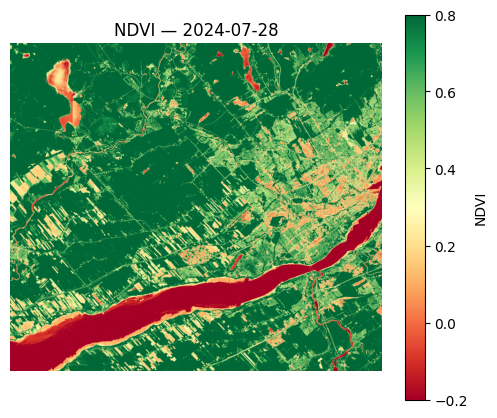

In [86]:
import matplotlib.pyplot as plt

# Creating a figure
plt.figure(figsize=(6, 5))

# Displaying the NDVI with a palette suited to vegetation (red-yellow-green)
# vmin/vmax: typical linear stretch for NDVI (-0.2 -> water/clouds to 0.8 (dense vegetation))
plt.imshow(ndvi, cmap="RdYlGn", vmin=-0.2, vmax=0.8)

# Color bar with the NDVI scale
plt.colorbar(label="NDVI")

# Title with the date of the Sentinel-2 scene
plt.title(f"NDVI: {sentinel_item.datetime:%Y-%m-%d}")


plt.axis("off")
plt.show()

### 2.2 Annual Crop Inventory (AAFC) → GeoParquet

The Annual Crop Inventory of Agriculture and Agri-Food Canada (AAFC)
is not ingested into the Agri-SDSS platform. It is queried on demand on its public ArcGIS REST service. Here we retrieve a raster of
crop codes for the AOI and join it to our sample of BDPPAD parcels,
first reprojecting the parcels to EPSG:4326.

`interpolation=RSP_NearestNeighbor` is essential: crop codes are
categorical, an interpolating resampling would invent codes that do not
exist.

In [87]:
import io
import requests
from rasterio.mask import mask

# Generates the extract locally from vector-api if missing (e.g. Québec/Estrie scenarios)
if not BDPPAD_DEMO_PATH.exists():
    print(f"No local extract for “{SCENARIO}”. Generating from vector-api...")
    try:
        parcels_from_api = fetch_bdppad_parcels_from_api(AOI_BBOX, AAC_YEAR)
    except requests.RequestException as exc:
        raise RuntimeError(
            f"vector-api unreachable at {VECTOR_API_URL} ({exc}). Cannot generate "
            "the BDPPAD extract for this scenario. Try again or switch back to the Montérégie scenario."
        ) from exc
    BDPPAD_DEMO_PATH.parent.mkdir(parents=True, exist_ok=True)
    parcels_from_api.to_file(BDPPAD_DEMO_PATH, driver="GPKG")
    print(f"Extract generated and cached: {BDPPAD_DEMO_PATH} ({len(parcels_from_api)} parcels)")

#  Loading the BDPPAD parcels (existing file or the one just generated)
parcels = gpd.read_file(BDPPAD_DEMO_PATH)
parcels = parcels.to_crs("EPSG:4326")  # CRS harmonization

# Spatial filter to select the parcels intersecting the AOI
parcels_aoi = parcels.cx[AOI_BBOX[0]:AOI_BBOX[2], AOI_BBOX[1]:AOI_BBOX[3]]

# Limiting to a sample of x for the example
sample_parcels = parcels_aoi.iloc[:500].copy()
print(
    f"{len(parcels_aoi)} BDPPAD parcels in the AOI; "
    f"keeping {len(sample_parcels)} for the example"
)

# Request to the cloud service of Agriculture and Agri-Food Canada (AAFC)
# Service that returns a raster image with crop codes per pixel
minx, miny, maxx, maxy = sample_parcels.total_bounds
export_url = (
    "https://agriculture.canada.ca/imagery-images/rest/services/"
    f"inventaire_annuel_des_cultures/{AAC_YEAR}/ImageServer/exportImage"
)
params = {
    "bbox": f"{minx},{miny},{maxx},{maxy}", # spatial extent
    "bboxSR": 4326,
    "size": "1024,1024",
    "imageSR": 4326,
    "format": "tiff",
    "pixelType": "U8",
    "noData": 0,
    "interpolation": "RSP_NearestNeighbor", # resampling method
    "f": "image",
}

try:
    # HTTP request to the AAFC service
    response = requests.get(export_url, params=params, timeout=30)
    response.raise_for_status()

    # Reading the returned raster
    with rasterio.open(io.BytesIO(response.content)) as aac_src:
        codes = []

        # For each parcel, extract the dominant crop code
        for geom in sample_parcels.geometry:
            try:
                # mask(): intersection of the parcel geometry and the crop code
                clipped, _ = mask(aac_src, [geom.__geo_interface__], crop=True)
                values = clipped[0]
                values = values[values != 0]

                # Filter the nodata pixels and extract the dominant class
                codes.append(
                    int(np.bincount(values).argmax()) if values.size else None
                )
            except ValueError:
                codes.append(None)  # parcel outside the retrieved extent

    sample_parcels["aac_crop_code"] = codes
    n_found = sample_parcels["aac_crop_code"].notna().sum()
    print(
        f"AAFC {AAC_YEAR} crop code assigned to "
        f"{n_found}/{len(sample_parcels)} parcels"
    )


except (requests.RequestException, rasterio.errors.RasterioIOError) as exc: # network error handling
    print(
        f"Call to the AAFC service failed ({exc}). Section skipped, "
        "the rest of the notebook continues."
    )
    sample_parcels["aac_crop_code"] = None


# Exporting the results to GeoParquet for cloud publication
aac_parquet_path = OUTPUT_DIR / "aac_crop_by_parcel.parquet"
sample_parcels.to_parquet(aac_parquet_path)
print(f"GeoParquet written: {aac_parquet_path} ({len(sample_parcels)} rows)")

No local extract for “Québec (Portneuf)”. Generating from vector-api...
Extract generated and cached: /content/drive/MyDrive/Formation RQRAD/bdppad_demo_quebec_2025.gpkg (3930 parcels)
3930 BDPPAD parcels in the AOI; keeping 500 for the example
AAFC 2024 crop code assigned to 500/500 parcels
GeoParquet written: formation_output/aac_crop_by_parcel.parquet (500 rows)


Creating a quick preview of the GeoParquet result as an interactive map

In [88]:
import folium
import pandas as pd

# Computing the AOI centroid to center the map
center_lat = (AOI_BBOX[1] + AOI_BBOX[3]) / 2
center_lon = (AOI_BBOX[0] + AOI_BBOX[2]) / 2

# Creating the map
aac_map = folium.Map(
    location=[center_lat, center_lon], zoom_start=13, tiles="cartodbpositron"
)

# Visual outline of the AOI (grey rectangle)
folium.Rectangle(
    bounds=[[AOI_BBOX[1], AOI_BBOX[0]], [AOI_BBOX[3], AOI_BBOX[2]]],
    color="#444444",
    fill=False,
    tooltip="AOI",
).add_to(aac_map)

# Displaying the parcels with their assigned AAFC crop codes
# Each parcel = geometry + interactive popup
for _, row in sample_parcels.iterrows():
    code = row.get("aac_crop_code")
    folium.GeoJson(
        row.geometry.__geo_interface__,
        tooltip=f"AAFC crop code: {'unknown' if pd.isna(code) else code}", # shows the AAFC code on hover (or "unknown" if missing)
        style_function=lambda _f: {"color": "#2b7a2b", "weight": 1, "fillOpacity": 0.5}, #  uniform style
    ).add_to(aac_map)

aac_map

### 2.3 Ouranos climate (ERA5-Land) → GeoParquet

The climate data processes of the Agri-SDSS platform read
the PAVICS THREDDS data through OPeNDAP + `xarray`/`pydap`. No authentication
is required. Here we reproduce exactly the same access for
**ERA5-Land** and compute a simple agronomic indicator: the growing degree
days (GDD) accumulated over the season for the area of interest (AOI).

We deliberately use ERA5-Land rather than RDRS or the CMIP6
projections: the latter two are on a rotated-pole grid,
which requires a much more complex 2D lat/lon masking. That is out of scope
for a one-hour workshop.

In [89]:
import requests
import xarray as xr
from pydap.client import open_url as pydap_open_url
import warnings
warnings.filterwarnings("ignore", message="PyDAP was unable to determine")

# URL of the Ouranos PAVICS cloud server
# Gives access to the ERA5-LAND climate analysis
OPENDAP_ERA5_LAND_URL = (
    "dap2://pavics.ouranos.ca/twitcher/ows/proxy/thredds/dodsC/"
    "datasets/reanalyses/day_ERA5-Land_NAM.ncml"
)

try:
    # Connection through PyDAP (Python client)
    # requests session = handling of HTTP headers, timeout and authentication
    pydap_session = requests.Session()
    pydap_store = pydap_open_url(
        OPENDAP_ERA5_LAND_URL, session=pydap_session, user_charset="utf-8"
    )

    # Opening the remote dataset as an xarray object
    era5 = xr.open_dataset(xr.backends.PydapDataStore(pydap_store))

    # Selecting the variables of interest (daily min/max temperature)
    era5 = era5[["tasmin", "tasmax"]]

    # Spatial selection: clipping to the AOI
    minx, miny, maxx, maxy = AOI_BBOX
    era5_aoi = era5.sel(lat=slice(miny, maxy), lon=slice(minx, maxx))

    # Temporal selection, average over all the pixels of the AOI
    era5_season = (
        era5_aoi.sel(time=slice(START_DATE, END_DATE))
        .mean(dim=["lat", "lon"])
        .load() # download from the server
    )

    # Kelvin -> Celsius conversion
    tasmin_c = era5_season["tasmin"].values - 273.15
    tasmax_c = era5_season["tasmax"].values - 273.15

    # Daily mean temperature
    tmean_c = (tasmin_c + tasmax_c) / 2.0

    # Computing the GDD (Growing Degree Days), used for several aspects in agriculture
    gdd_daily = np.clip(tmean_c - GDD_BASE_TEMP, a_min=0, a_max=None)

    # Cumulative sum of the GDD over the season
    gdd_cumulative = float(np.nansum(gdd_daily))
    n_days = len(gdd_daily)
    print(
        f"Cumulative GDD (base {GDD_BASE_TEMP}°C) from {START_DATE} to {END_DATE}: "
        f"{gdd_cumulative:.0f} °C-days over {n_days} days"
    )

# Error handling
except Exception as exc:
    print(
        f"PAVICS/OPeNDAP access failed ({exc}). Section skipped, "
        "the rest of the notebook continues."
    )
    gdd_cumulative, n_days = None, 0

# Creating a GeoDataFrame with the climate results
# Stored at the AOI centroid with metadata (dates, threshold, parameters)
aoi_centroid = Point((AOI_BBOX[0] + AOI_BBOX[2]) / 2, (AOI_BBOX[1] + AOI_BBOX[3]) / 2)
climate_gdf = gpd.GeoDataFrame(
    {
        "indicator": ["gdd"], # indicator type
        "base_temp_c": [GDD_BASE_TEMP], # agronomic threshold used
        "start_date": [START_DATE],
        "end_date": [END_DATE],
        "value": [gdd_cumulative], # total GDD
        "n_days": [n_days],
    },
    geometry=[aoi_centroid],
    crs="EPSG:4326",
)

# Exporting the results to GeoParquet for cloud publication
climate_parquet_path = OUTPUT_DIR / "era5_land_gdd.parquet"
climate_gdf.to_parquet(climate_parquet_path)
print(f"GeoParquet written: {climate_parquet_path}")

Cumulative GDD (base 10°C) from 2024-06-01 to 2024-08-31: 906 °C-days over 92 days
GeoParquet written: formation_output/era5_land_gdd.parquet


Creating a figure to illustrate the GDD analysis of the AOI

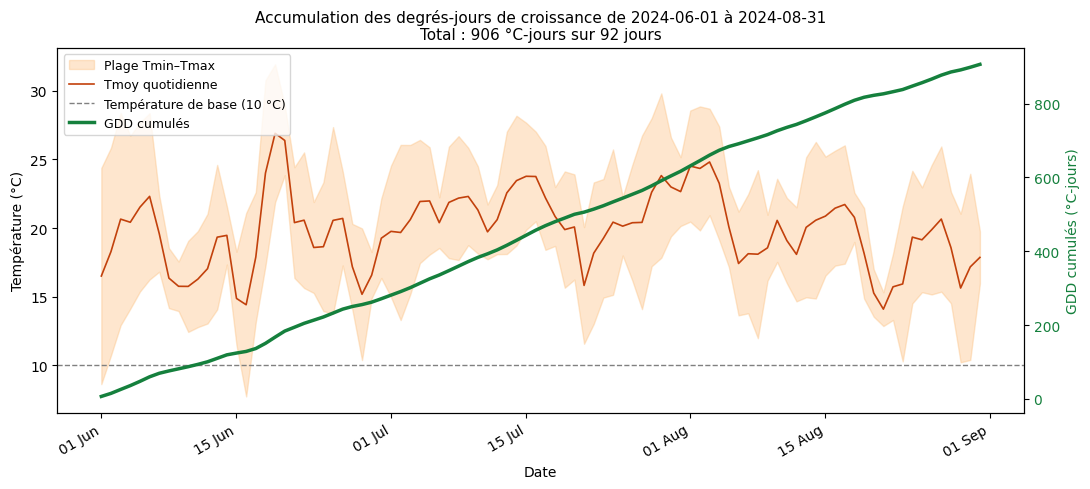

In [90]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Check
if gdd_cumulative is None:
    print("No climate data (OPeNDAP access failed). Nothing to plot.")
else:
    # Extracting the time axis and computing the daily GDD accumulation
    dates = era5_season["time"].values
    gdd_cumul_curve = np.cumsum(gdd_daily)   # running sum: GDD day 1, day 1+2, etc

    # Creating the figure with two axes
    fig, ax1 = plt.subplots(figsize=(11, 5))

    # Left axis (ax1): daily temperatures
    # Colored band for a quick reading of the variability
    ax1.fill_between(dates, tasmin_c, tasmax_c, color="#fdba74", alpha=0.35,
                     label="Tmin–Tmax range")

    # Mean temperature curve
    ax1.plot(dates, tmean_c, color="#c2410c", lw=1.2, label="Daily Tmean")

    # Horizontal line = GDD base threshold
    ax1.axhline(GDD_BASE_TEMP, color="gray", ls="--", lw=1,
                label=f"Base temperature ({GDD_BASE_TEMP} °C)")
    ax1.set_ylabel("Temperature (°C)")
    ax1.set_xlabel("Date")

    # Right axis (ax2): cumulative GDD over the season
    ax2 = ax1.twinx()
    ax2.plot(dates, gdd_cumul_curve, color="#15803d", lw=2.5,
             label="Cumulative GDD")
    ax2.set_ylabel("Cumulative GDD (°C-days)", color="#15803d")
    ax2.tick_params(axis="y", labelcolor="#15803d")

    # Formatting the date axis
    ax1.xaxis.set_major_formatter(mdates.DateFormatter("%d %b"))
    fig.autofmt_xdate()

    # Combined legend of both axes
    lignes1, labels1 = ax1.get_legend_handles_labels()
    lignes2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lignes1 + lignes2, labels1 + labels2, loc="upper left", fontsize=9)

    # Title with context
    plt.title(
        f"Growing degree day accumulation from {START_DATE} to {END_DATE}\n"
        f"Total: {gdd_cumulative:.0f} °C-days over {n_days} days",
        fontsize=11,
    )

    # Displaying the figure
    plt.tight_layout()
    plt.show()

## 3. Cataloguing the three layers with STAC

We now assemble a local STAC Collection describing the three
layers produced.

In [91]:
import datetime as dt
import pystac
from shapely.geometry import box, mapping

# Directory of the STAC catalog
catalog_dir = OUTPUT_DIR / "stac_catalog"

# Preparing the geometry and the spatial metadata
aoi_geometry = mapping(box(*AOI_BBOX))
aoi_bbox_list = list(AOI_BBOX)


# ITEM 1 --- NDVI (COG raster)
# Temporal metadata
ndvi_datetime = sentinel_item.datetime or dt.datetime.now(dt.timezone.utc)

# Creating a STAC Item for the NDVI layer
# Item = container for metadata + assets (data files)
ndvi_item = pystac.Item(
    id="sentinel2_ndvi_formation_demo", # unique identifier of the Item
    geometry=aoi_geometry, # spatial coverage
    bbox=aoi_bbox_list, # spatial extent
    datetime=ndvi_datetime, # acquisition date
    properties={ # metadata
        "description": "Sentinel-2 NDVI composite for the demonstration area",
        "source": "planetary-computer/sentinel-2-l2a",
    },
)

# Adding the asset (link to the NDVI COG file)
ndvi_item.add_asset(
    "ndvi",
    pystac.Asset(
        href=str(ndvi_cog_path.resolve()), # absolute path of the file
        media_type=pystac.MediaType.COG, # here, COG = raster optimized for tiles
        roles=["data"], # semantic role (data vs metadata)
    ),
)

# ITEM 2 --- AAFC crop (GeoParquet vector)
aac_item = pystac.Item(
    id="aac_crop_by_parcel",
    geometry=aoi_geometry,
    bbox=aoi_bbox_list,
    datetime=dt.datetime(AAC_YEAR, 1, 1, tzinfo=dt.timezone.utc),
    properties={
        "description": f"AAFC {AAC_YEAR} crop code per BDPPAD parcel",
        "source": "agriculture.canada.ca AAC ImageServer",
    },
)

# Adding the asset (link to the GeoParquet file)
aac_item.add_asset(
    "data",
    pystac.Asset(
        href=str(aac_parquet_path.resolve()),
        media_type="application/x-parquet", # Parquet format
        roles=["data"],
    ),
)

# ITEM 3 --- Cumulative GDD (GeoParquet vector)
climate_item = pystac.Item(
    id="era5_land_gdd",
    geometry=aoi_geometry,
    bbox=aoi_bbox_list,
    datetime=dt.datetime.strptime(END_DATE, "%Y-%m-%d").replace(tzinfo=dt.timezone.utc),
    properties={
        "description": "Cumulative growing degree days (ERA5-Land, PAVICS)",
        "source": "PAVICS THREDDS era5_land",
    },
)

# Adding the asset (link to the GeoParquet file)
climate_item.add_asset(
    "data",
    pystac.Asset(
        href=str(climate_parquet_path.resolve()),
        media_type="application/x-parquet", # Parquet format
        roles=["data"],
    ),
)

# CREATING THE STAC COLLECTION
# Collection = grouping of Items sharing a spatio-temporal coverage
stac_items = [ndvi_item, aac_item, climate_item]
collection = pystac.Collection(
    id="formation_som_layers",
    description=(
        "Layers prepared for the spatial model of soil organic matter "
        "accumulation potential (RQRAD)"
    ),
    # Defining the full spatial and temporal extent of the Collection
    extent=pystac.Extent(
        spatial=pystac.SpatialExtent([aoi_bbox_list]),
        temporal=pystac.TemporalExtent( # min/max of the datetimes of all the Items
            [
                [
                    min(it.datetime for it in stac_items),
                    max(it.datetime for it in stac_items),
                ]
            ]
        ),
    ),
)

# Adding all the Items to the Collection
for stac_item in stac_items:
    collection.add_item(stac_item)


# Path normalization: conversion to relative paths
collection.normalize_hrefs(str(catalog_dir))
collection.make_all_asset_hrefs_relative()

# Validation against the official STAC schema, detects structural errors in the spatio-temporal metadata
collection.validate_all()

# Saving, writing the JSON files
collection.save(catalog_type=pystac.CatalogType.SELF_CONTAINED) # SELF_CONTAINED: generates a self-sufficient catalog.json
print(
    f"STAC catalog (1 collection, {len(stac_items)} items) "
    f"saved to: {catalog_dir}"
)

STAC catalog (1 collection, 3 items) saved to: formation_output/stac_catalog


### 3.1 Visualize the STAC
We can then see the metadata of our STAC Items on a map.

In [92]:
import folium
import pystac
import rasterio
import geopandas as gpd

# Loading the STAC Collection from the .json file
loaded = pystac.Collection.from_file(str(catalog_dir / "collection.json"))

# Creating the map
minx, miny, maxx, maxy = AOI_BBOX
m = folium.Map(location=[(miny + maxy) / 2, (minx + maxx) / 2], zoom_start=11)

# Map color palette, one hue per layer type
colors = {
    "sentinel2_ndvi_formation_demo": "green",
    "aac_crop_by_parcel": "orange",
    "era5_land_gdd": "blue",
}

# Function that opens the assets and extracts their metadata
def describe_assets(item):
    """Actually open each asset and extract its real metadata."""
    lines = []
    for key, asset in item.assets.items():
        # Converting the relative href into an absolute path
        path = asset.get_absolute_href()
        try:
            # --- Raster ---
            if "geotiff" in (asset.media_type or ""):
                with rasterio.open(path) as src:
                    band = src.read(1, masked=True)
                    lines.append(
                        f"<b>{key}</b> (raster)<br>"
                        f"&nbsp;&nbsp;{src.width}×{src.height} px · {src.crs}<br>"
                        f"&nbsp;&nbsp;dtype {src.dtypes[0]}<br>"
                        f"&nbsp;&nbsp;min {band.min():.3f} / "
                        f"mean {band.mean():.3f} / max {band.max():.3f}"
                    )
            # --- Vector ---
            elif "parquet" in (asset.media_type or ""):
                gdf = gpd.read_parquet(path)

                # Preview: first feature, filled columns only, no null value
                row = gdf.drop(columns="geometry", errors="ignore").iloc[0]
                filled = row.dropna()
                filled = filled[filled.astype(str).str.strip().ne("")]

                # Limited to 8 fields to keep the popup readable and fast
                preview_html = "<br>".join(
                    f"&nbsp;&nbsp;{k} = {v}" for k, v in filled.head(8).items()
                )
                lines.append(
                    f"<b>{key}</b> (table · {len(gdf)} features · "
                    f"{gdf.shape[1] - 1} columns)<br>"
                    f"&nbsp;&nbsp;<i>preview of 1st feature (filled fields):</i><br>"
                    f"{preview_html}"
                )
        except Exception as exc:
            # Fallback if the asset cannot be opened
            lines.append(f"<b>{key}</b>: cannot be read ({exc})")

    return "<hr style='margin:4px 0'>".join(lines)

# Displaying each STAC Item on the map
for item in loaded.get_items():
    # Building the popups: metadata + preview of the assets
    popup = folium.Popup(
        f"<b>{item.id}</b> · {item.datetime:%Y-%m-%d}<br>"
        f"<i>{item.properties.get('description', '')}</i>"
        f"<hr style='margin:4px 0'>{describe_assets(item)}",
        max_width=380,
    )

    # Cartographic rendering on the map, we get the color for each item
    folium.GeoJson(
        item.geometry,
        name=item.id,
        style_function=lambda _, c=colors.get(item.id, "red"): {
            "color": c, "weight": 2, "fillOpacity": 0.08
        },
        popup=popup,
        tooltip=item.id,
    ).add_to(m)

folium.LayerControl(collapsed=False).add_to(m)
m

## 4. Consuming these same formats through the Agri-SDSS OGC APIs

This section is independent from everything above: it queries the
production stack of Agri-SDSS, not the files
we just produced. The goal is to show how these same cloud-native
formats are exposed in production, once ingested.

If the server is not running, the two cells below say so
clearly.

### 4.1 Return the parcels inside our AOI

In [93]:
VECTOR_API_URL="https://agri-sdss.duckdns.org/vector-api/"

try:
    # Request to the platform's Vector API service (OGC API Features): listing the available Collections
    resp = requests.get(f"{VECTOR_API_URL}/postgis/collections", timeout=10)
    resp.raise_for_status()
    vector_collections = resp.json().get("collections", [])

    # Filtering the Collections: looking for the keyword "bdppad" for the agricultural parcels
    bdppad_collections = [
        c for c in vector_collections
        if "bdppad" in str(c.get("id") or "").lower()
    ]

    # Error handling if no collection is found
    if not bdppad_collections:
        print(
            f"{len(vector_collections)} collection(s) found on vector-api, "
            "but none matches 'bdppad'. Did you load the demonstration "
            "data (see the README, “Quick start” section)?"
        )
    else:
        # Selecting the first collection found
        target_collection_id = bdppad_collections[0]["id"]
        print(f"Collection found on vector-api: {target_collection_id}")

        # Spatial query parameters: filter by the area of interest (AOI)
        minx, miny, maxx, maxy = AOI_BBOX
        page_size = 1000            # number of features per request
        offset = 0                  # starting index
        vector_features = []        # accumulation of the features

        # Pagination loop
        # Request: retrieving the Items (parcels) within the AOI
        # Parameters: spatial extent (bbox) + pagination (limit + offset)
        while True:
            items_resp = requests.get(
                f"{VECTOR_API_URL}/postgis/collections/{target_collection_id}/items",
                params={
                    "bbox": f"{minx},{miny},{maxx},{maxy}", # spatial filtering
                    "limit": page_size,                     # page size
                    "offset": offset,                       # starting index
                },
                timeout=30,
            )
            items_resp.raise_for_status()

            # Extracting the features
            page = items_resp.json().get("features", [])
            vector_features.extend(page)

            # Stop condition if the returned page < page size, so no more data
            if len(page) < page_size:
                break

            # Otherwise, advance the offset for the next request
            offset += page_size

        print(
            f"{len(vector_features)} parcel(s) returned by vector-api "
            "within the AOI (all)"
        )

except requests.RequestException as exc:
    # Network error handling
    print(
        f"vector-api is not reachable at {VECTOR_API_URL} ({exc}). "
        "Start the stack with `docker compose up -d` to test this section."
    )

Collection found on vector-api: public.bdppad_v03_an_2022_s_20240101
3976 parcel(s) returned by vector-api within the AOI (all)


### 4.2 We can also display these parcels on a map
Here we set a limit of 500 again for the sake of the demonstration.

In [94]:
import folium

# Spatial parameters
minx, miny, maxx, maxy = AOI_BBOX

# Request to the platform's Vector API service: retrieving the parcels within the AOI
# Limited to 500 for performance reasons
items_resp = requests.get(
    f"{VECTOR_API_URL}/postgis/collections/{target_collection_id}/items",
    params={"bbox": f"{minx},{miny},{maxx},{maxy}", "limit": 500},
    timeout=30,
)
items_resp.raise_for_status()

# Parsing the OGC API Features response
feature_collection = items_resp.json()
features = feature_collection.get("features", [])
print(f"{len(features)} parcel(s) retrieved through vector-api")

# Creating the map
m = folium.Map(location=[(miny + maxy) / 2, (minx + maxx) / 2], zoom_start=13)

# Displaying the BDPPAD parcels with a uniform style
# GeoJsonPopup/GeoJsonTooltip = interactive configuration for each feature
folium.GeoJson(
    feature_collection,
    name="BDPPAD parcels (vector-api)",
    style_function=lambda _: {
        "color": "#c2410c", "weight": 1, "fillColor": "#f97316", "fillOpacity": 0.25
    },
    popup=folium.GeoJsonPopup(
        fields=["idpar", "suphec", "gropro", "desgropro"],
        aliases=["Parcel", "Area (ha)", "Production group", "Description"],
    ),
    # Shows the parcel ID only
    tooltip=folium.GeoJsonTooltip(fields=["idpar"]),
).add_to(m)

# Visual outline of the area of interest (AOI) in red
folium.Rectangle(
    bounds=[[miny, minx], [maxy, maxx]],
    color="red", weight=2, fill=False, tooltip="AOI_BBOX",
).add_to(m)

folium.LayerControl().add_to(m)
m

Output hidden; open in https://colab.research.google.com to view.

### 4.3 Same principle for raster data

In [95]:
from urllib.parse import quote

RASTER_API_URL="https://agri-sdss.duckdns.org/raster-api/"

try:
    # Access to a public Sentinel-2 COG (hosted on Microsoft Planetary Computer)
    # This COG is not in the Agri-SDSS repository, but is reachable through a public URL
    public_cog_href = sentinel_item.assets["B04"].href

    # Request to the platform's Raster API service: extracting the metadata of the Sentinel-2 COG
    # /cog/info = endpoint to inspect structure, size, CRS, bands, overviews
    info_resp = requests.get(
        f"{RASTER_API_URL}/cog/info", params={"url": public_cog_href}, timeout=15
    )
    info_resp.raise_for_status()
    cog_info = info_resp.json()

    # Displaying the key metadata of the COG
    print("raster-api /cog/info on a public Sentinel-2 COG:")
    for key in ("width", "height", "crs", "count", "overviews"):
        if key in cog_info:
            print(f"  {key}: {cog_info[key]}")

    # Building a PNG preview URL (server-side rendering)
    # ⚠️ IMPORTANT: public_cog_href contains a SAS authentication token (Azure)
    # with its own special characters (& and =) → it must be URL-encoded before
    # being nested in the query string parameters of the preview URL.
    # quote(href, safe='') = encodes ALL the special characters
    preview_url = (
        f"{RASTER_API_URL}/cog/preview.png"
        f"?url={quote(public_cog_href, safe='')}&rescale=0,3000&bidx=1"
    )
    print(f"\nPreview (to open in a browser): {preview_url}")

    # Teaching note: raster-api is agnostic to the source
    # It can serve any public/authenticated COG by URL,
    # not only those registered in the Agri-SDSS repository
    print(
        "\nThis COG was never ingested into Agri-SDSS: the platform's API can "
        "serve any COG reachable by URL, not only those of the platform."
    )

except requests.RequestException as exc:
    # Network error handling
    print(
        f"raster-api is not reachable at {RASTER_API_URL} ({exc})"
    )

raster-api /cog/info on a public Sentinel-2 COG:
  width: 10980
  height: 10980
  crs: http://www.opengis.net/def/crs/EPSG/0/32619
  count: 1
  overviews: [2, 4, 8, 16]

Preview (to open in a browser): https://agri-sdss.duckdns.org/raster-api//cog/preview.png?url=https%3A%2F%2Fsentinel2l2a01.blob.core.windows.net%2Fsentinel2-l2%2F19%2FT%2FCN%2F2024%2F07%2F28%2FS2A_MSIL2A_20240728T154941_N0511_R054_T19TCN_20240728T232052.SAFE%2FGRANULE%2FL2A_T19TCN_A047527_20240728T155158%2FIMG_DATA%2FR10m%2FT19TCN_20240728T154941_B04_10m.tif%3Fst%3D2026-08-24T04%253A32%253A20Z%26se%3D2026-08-25T05%253A17%253A20Z%26sp%3Drl%26sv%3D2025-07-05%26sr%3Dc%26skoid%3D9c8ff44a-6a2c-4dfb-b298-1c9212f64d9a%26sktid%3D72f988bf-86f1-41af-91ab-2d7cd011db47%26skt%3D2026-08-25T04%253A20%253A26Z%26ske%3D2026-09-01T04%253A20%253A26Z%26sks%3Db%26skv%3D2025-07-05%26sig%3D9DU6JQ6jC%252BhU6bDfsdUZIoI%252BBHuSQ4OJP%252BiNow%2FA9Go%253D&rescale=0,3000&bidx=1

This COG was never ingested into Agri-SDSS: the platform's API can se

## Conclusion

This notebook provides a demonstration of how to query cloud data available in open access from public providers. It also presents the broad steps for producing your own cloud-native data, ready to be published and queried by users.

| Open data queried | Cloud-native format produced |
| --- | --- |
| Sentinel-2 (Planetary Computer) | COG (NDVI) |
| AAFC Annual Crop Inventory | GeoParquet (1 parcel = 1 polygon) |
| Ouranos / PAVICS (ERA5-Land) | GeoParquet (1 area of interest = 1 polygon) | |
| (none) | STAC catalog |

These three layers (NDVI, land cover, climate) are equivalent to
those consumed by the platform's soil organic matter predictive models. See the [`associated presentation from the 5th annual RQRAD congress`](https://rqrad.com/evenement/5e-congres-annuel-du-rqrad/?session=5081) for more information on the models.

### To go further with cloud-native formats in remote sensing
- [COG](https://www.ogc.org/standards/ogc-cloud-optimized-geotiff/)
- [STAC](https://stacspec.org/en)
- [GeoParquet](https://geoparquet.org/)
- [OGC API](https://ogcapi.ogc.org/)

### To go further with the platform
- [`Agri-SDSS source code`](https://github.com/jeremie-durand/Agri-SDSS): GitHub of the platform
- [`Agri-SDSS`](https://agri-sdss.duckdns.org/): user interface of the platform
- [`docs/ARCHITECTURE.md`](https://github.com/jeremie-durand/Agri-SDSS/blob/develop/docs/ARCHITECTURE.md): technical overview of the
  Agri-SDSS platform
- [`docs/data/CATALOG.md`](https://github.com/jeremie-durand/Agri-SDSS/blob/develop/docs/data/CATALOG.md): inventory of the integrated data
  sources
- [`gis-pipeline`](https://github.com/jeremie-durand/Agri-SDSS/tree/develop/gis-pipeline): the full production pipeline
  (validation, CRS harmonization, standardization, PostGIS, GeoParquet, STAC)